This project proposes a machine learning framework to analyze and quantify simulation biases between Pythia and Herwig event generators. By engineering invariant and rest-frame kinematic observables—such as jet mass, multiplicity, and energy dispersion—we establish a robust physical baseline. The core objective is to leverage interpretable ML classifiers to distinguish between quark and gluon jets, utilizing the model's feature weights to pinpoint exactly where the two simulators diverge in their theoretical modeling. This data-driven approach will isolate generator-specific biases, ultimately providing actionable insights to refine simulations for future collider experiments.

In [ ]:
import numpy as np

data = np.load("QG_jets.npz")

X = data['X']
y = data['y']

print (f"X shape: {X.shape}")
print (f"Y Shape: {y.shape}")
valid = X[:,:,0] > 0
print (f"Valid shape: {valid.shape}")
total = np.sum(valid)



X shape: (100000, 139, 4)
Y Shape: (100000,)
Valid shape: (100000, 139)


In [ ]:
gluon = (y==0)
quark = (y==1)

gluon_constituents = np.sum(valid[gluon])
quark_constituents = np.sum(valid[quark])
print (f"Total Gluon Constituents: {gluon_constituents}")
print (f"Total Quark Constituents: {quark_constituents}")


Total Gluon Constituents: 2660906
Total Quark Constituents: 1669999


In [ ]:
multiplicity = np.sum(valid, axis = 1)

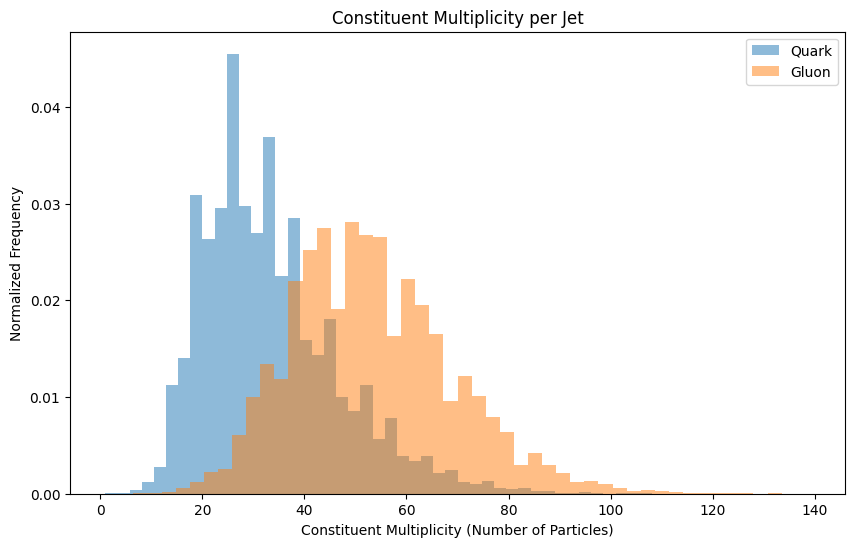

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize = (10,6))
plt.hist(multiplicity[quark], bins=50, alpha=0.5, label='Quark', density=True)
plt.hist(multiplicity[gluon], bins=50, alpha=0.5, label='Gluon', density=True)
plt.xlabel('Constituent Multiplicity (Number of Particles)')
plt.ylabel('Normalized Frequency')
plt.title('Constituent Multiplicity per Jet')
plt.legend()
plt.show()

In [ ]:
leading_indices = np.argmax(X[:,:,0], axis = 1)
jet_indices = np.arange(X.shape[0])
leading_pt = X[jet_indices, leading_indices, 0]
leading_n = X[jet_indices, leading_indices, 1]

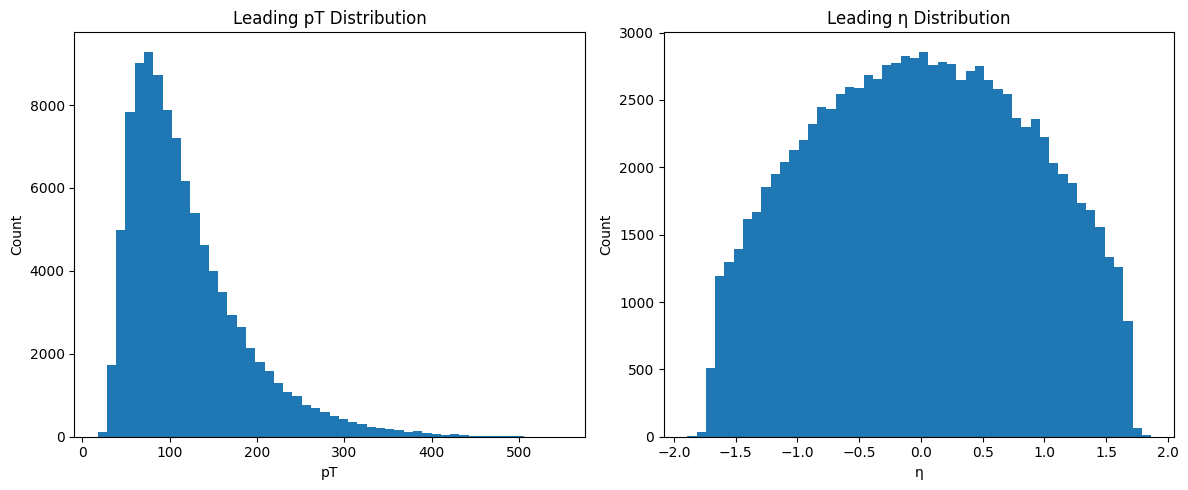

In [ ]:

plt.figure(figsize=(12,5))

# Subplot 1 — Leading pT
plt.subplot(1, 2, 1)
plt.hist(leading_pt, bins=50)
plt.title("Leading pT Distribution")
plt.xlabel("pT")
plt.ylabel("Count")

# Subplot 2 — Leading eta
plt.subplot(1, 2, 2)
plt.hist(leading_n, bins=50)
plt.title("Leading η Distribution")
plt.xlabel("η")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

## Part (b): Jet Observables

**Methodology:**
To calculate the observables, I vectorized the math across the dataset using NumPy. First, I converted the given `(pT, eta, phi)` into Cartesian 4-momenta.
- **Jet Mass:** Summed the energy and momentum components across the `axis=1` and applied the invariant mass formula.
- **Jet Width & pT Dispersion:** Calculated the overall jet axis (`Pt_jet`, `phi_J`, `eta_J`) first. I had to make sure to use the sum of $p_T$ rather than the padded valid flags in the denominator to avoid `NaN` errors.

conversion to four momenta:

In [ ]:
pt = X[:, :, 0]
eta = X[:, :, 1]
phi = X[:, :, 2]

# Convert to Cartesian 4-momenta
px = pt * np.cos(phi)
py = pt * np.sin(phi)
pz = pt * np.sinh(eta)
e = pt * np.cosh(eta)

print(f"px shape: {px.shape}")
print(f"Energy shape: {e.shape}")

px shape: (100000, 139)
Energy shape: (100000, 139)


calculating jet mass:

In [ ]:
#components sum
px_jet = np.sum(px, axis = 1)
py_jet = np.sum(py, axis = 1)
pz_jet = np.sum(pz, axis = 1)
e_jet = np.sum(e, axis = 1)
#squared sum of the component sums
momentum_sq = px_jet**2 + py_jet**2 + pz_jet**2
#invariant jet mass formula
jet_mass = np.sqrt(np.maximum(0, e_jet**2 - momentum_sq))
print (f"Jet mass shape: {jet_mass.shape}")

Jet mass shape: (100000,)


###(ii) Jet width.

Finding Jet Axis

In [ ]:
# total momentum components for the ENTIRE jet first
total_pt_jet = np.sqrt(px_jet**2 + py_jet**2)
# Calculate the jet axis using
phi_J_axis = np.arctan2(py_jet, px_jet)
eta_J_axis = np.arcsinh(pz_jet / total_pt_jet)
# Calculate distance
d_eta = eta - eta_J_axis[:, np.newaxis]
d_phi = phi - phi_J_axis[:, np.newaxis]
d_phi = (d_phi + np.pi) % (2 * np.pi) - np.pi # This forces d_phi between -pi and pi
delta_R = np.sqrt(np.maximum(0,d_eta**2 + d_phi**2))

Finding numerator, denominator and width

In [ ]:
numerator = np.sum(delta_R * valid, axis = 1)
denominator = np.sum(pt, axis = 1)
width = numerator/denominator

### (iii) pT dispersion (pDT)

In [ ]:
pt_sq = pt**2
pt_dispersion = (np.sqrt(np.sum(pt_sq, axis = 1)))/denominator


### Plotting of all 3 results

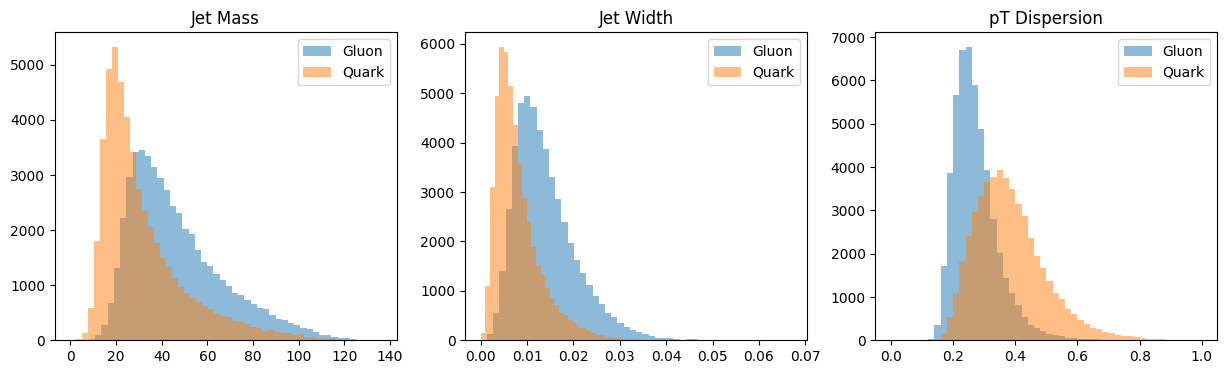

In [ ]:
# Create a figure with 3 side-by-side plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Plot Jet Mass
axes[0].hist(jet_mass[gluon], bins=50, alpha=0.5, label='Gluon')
axes[0].hist(jet_mass[quark], bins=50, alpha=0.5, label='Quark')
axes[0].set_title('Jet Mass')
axes[0].legend()

# 2. Plot Jet Width
axes[1].hist(width[gluon], bins=50, alpha=0.5, label='Gluon')
axes[1].hist(width[quark], bins=50, alpha=0.5, label='Quark')
axes[1].set_title('Jet Width')
axes[1].legend()

# 3. Plot pT Dispersion
axes[2].hist(pt_dispersion[gluon], bins=50, range=(0, 1), alpha=0.5, label='Gluon')
axes[2].hist(pt_dispersion[quark], bins=50, range=(0, 1), alpha=0.5, label='Quark')
axes[2].set_title('pT Dispersion')
axes[2].legend()

plt.show()

## Part (c): Boost to the Jet Center-of-Mass Frame

**Methodology:**
For the boost, I wrote a function that calculates the boost vector $\vec{\beta}$ by dividing the jet's total 3-momentum by its total energy. I applied standard Lorentz transformations to calculate the new constituent momenta.

*(Note: I added a tiny `np.clip` to $\beta^2$ to keep it strictly below 1.0, which prevents floating-point rounding errors from breaking the square root in the gamma calculation).*

In relativity, the boost vector $\vec{\beta}$ describes the velocity of the moving frame (the jet) relative to the lab.In terms of the jet's four-momentum, it is simply the jet's total 3-momentum divided by its total energy:$$\vec{\beta} = \frac{\vec{P}_J}{E_J} = \left( \frac{P_x}{E_J}, \frac{P_y}{E_J}, \frac{P_z}{E_J} \right)$$

In [ ]:
def boost_to_rest_frame(jet_constituents):
    """
    Takes an N x 4 array of constituent four-momenta (E, px, py, pz)
    and returns the N x 4 array in the jet rest frame.
    """
    # 1. Total jet momentum and energy
    E_J = np.sum(jet_constituents[:, 0])
    px_J = np.sum(jet_constituents[:, 1])
    py_J = np.sum(jet_constituents[:, 2])
    pz_J = np.sum(jet_constituents[:, 3])

    # 2. Boost vector (beta) and Lorentz factor (gamma)
    bx = px_J / E_J
    by = py_J / E_J
    bz = pz_J / E_J

    b2 = np.clip(bx**2 + by**2 + bz**2, 0.0, 0.99999999) # Prevent divide-by-zero
    gamma = 1.0 / np.sqrt(1.0 - b2)

    # 3. Extract individual particle components
    E = jet_constituents[:, 0]
    px = jet_constituents[:, 1]
    py = jet_constituents[:, 2]
    pz = jet_constituents[:, 3]

    # 4. Apply Lorentz boost formula
    bp = bx * px + by * py + bz * pz
    gamma2 = (gamma - 1.0) / b2

    E_prime = gamma * (E - bp)
    px_prime = px + gamma2 * bp * bx - gamma * bx * E
    py_prime = py + gamma2 * bp * by - gamma * by * E
    pz_prime = pz + gamma2 * bp * bz - gamma * bz * E

    # Return the new four-momenta stacked together
    return np.column_stack((E_prime, px_prime, py_prime, pz_prime))

In [ ]:
# Example for testing the first jet (index 0)
single_jet_data = np.column_stack((e[0], px[0], py[0], pz[0]))
boosted_jet = boost_to_rest_frame(single_jet_data)

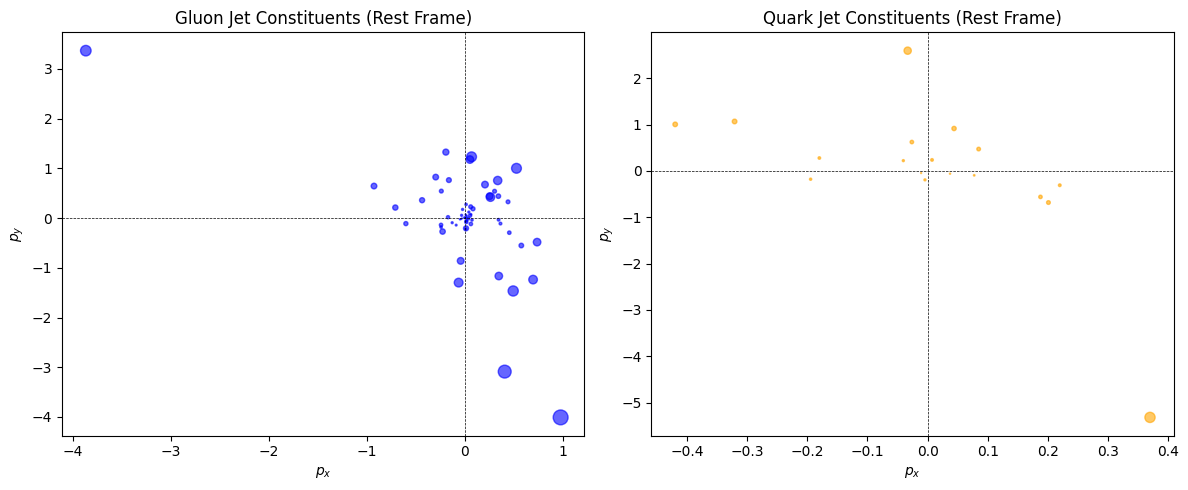

In [ ]:
import matplotlib.pyplot as plt

# 1. Find the index of the first real gluon jet (y==0) and quark jet (y==1)
gluon_idx = np.where(y == 0)[0][0]
quark_idx = np.where(y == 1)[0][0]

# 2. Extract their Lab Frame 4-momenta (E, px, py, pz)
gluon_lab = np.column_stack((e[gluon_idx], px[gluon_idx], py[gluon_idx], pz[gluon_idx]))
quark_lab = np.column_stack((e[quark_idx], px[quark_idx], py[quark_idx], pz[quark_idx]))

# 3. Apply the boost function
gluon_rest = boost_to_rest_frame(gluon_lab)
quark_rest = boost_to_rest_frame(quark_lab)

# 4. Filter out zero-padded particles using your valid mask
g_valid = valid[gluon_idx]
q_valid = valid[quark_idx]

g_rest_real = gluon_rest[g_valid]
q_rest_real = quark_rest[q_valid]

# 5. Plotting
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot Gluon Jet (Column 1 is px, Column 2 is py, Column 0 is E)
axes[0].scatter(g_rest_real[:, 1], g_rest_real[:, 2],
                s=g_rest_real[:, 0] * 10, alpha=0.6, c='blue')
axes[0].set_title('Gluon Jet Constituents (Rest Frame)')
axes[0].set_xlabel('$p_x$')
axes[0].set_ylabel('$p_y$')
axes[0].axhline(0, color='black', linewidth=0.5, linestyle='--')
axes[0].axvline(0, color='black', linewidth=0.5, linestyle='--')

# Plot Quark Jet
axes[1].scatter(q_rest_real[:, 1], q_rest_real[:, 2],
                s=q_rest_real[:, 0] * 10, alpha=0.6, c='orange')
axes[1].set_title('Quark Jet Constituents (Rest Frame)')
axes[1].set_xlabel('$p_x$')
axes[1].set_ylabel('$p_y$')
axes[1].axhline(0, color='black', linewidth=0.5, linestyle='--')
axes[1].axvline(0, color='black', linewidth=0.5, linestyle='--')

plt.tight_layout()
plt.show()

## Part (d): Quark vs. Gluon Classification

**Methodology:**
I chose a Logistic Regression classifier because it's fast, interpretable, and works well with a small feature space.
**Features chosen:**
1. Multiplicity (straightforward discriminator)
2. Jet Mass (invariant)
3. Rest-Frame Energy Dispersion (using the `e_prime` from the boosted frame)

I scaled the features using `StandardScaler` so the logistic regression weights can be directly compared to find the most discriminating feature.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# --- 1. Vectorized Boost (To get rest-frame energies for ALL jets) ---
e_jet = np.sum(e, axis=1)
bx, by, bz = px_jet / e_jet, py_jet / e_jet, pz_jet / e_jet
b2 = np.clip(bx**2 + by**2 + bz**2, 0.0, 0.99999999)
gamma = 1.0 / np.sqrt(1.0 - b2)

# Broadcast for the 2D arrays
bx_b, by_b, bz_b = bx[:, np.newaxis], by[:, np.newaxis], bz[:, np.newaxis]
gamma_b = gamma[:, np.newaxis]

bp = bx_b * px + by_b * py + bz_b * pz
e_prime = gamma_b * (e - bp) # Here is our e_prime!

# --- 2. Prepare Features ---
multiplicity = np.sum(valid, axis=1)

# Calculate Energy Dispersion in the rest frame using our new e_prime
e_prime_sq_sum = np.sum(e_prime**2, axis=1)
e_prime_sum = np.sum(e_prime, axis=1)

# Add 1e-12 to prevent divide-by-zero (NaN) errors
e_dispersion_rest = np.sqrt(e_prime_sq_sum) / (e_prime_sum + 1e-12)

# Stack into our X matrix
X_clf = np.column_stack((multiplicity, jet_mass, e_dispersion_rest))
feature_names = ['Multiplicity', 'Jet Mass', 'Rest-Frame E-Dispersion']

# Scale features (Critical for Logistic Regression)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clf)

# --- 3. Train/Test Split & Train ---
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

clf = LogisticRegression()
clf.fit(X_train, y_train)

y_prob = clf.predict_proba(X_test)[:, 1]
y_pred = clf.predict(X_test)

print("Model trained successfully!")

Model trained successfully!


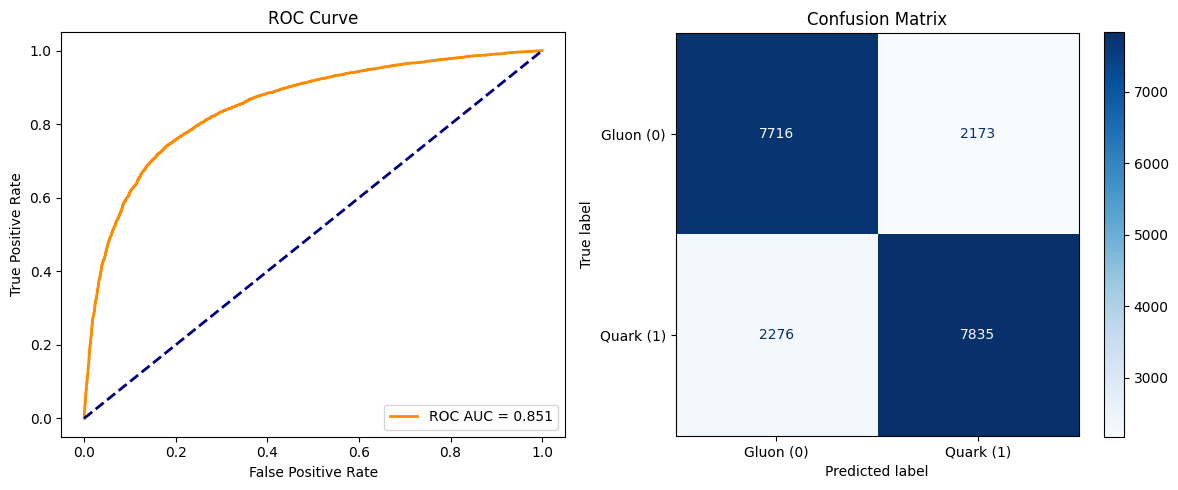

Most discriminating feature: Multiplicity (Weight: 1.33)


In [ ]:
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1. ROC Curve & AUC
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC AUC = {roc_auc:.3f}')
axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend(loc="lower right")

# 2. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Gluon (0)', 'Quark (1)'])
disp.plot(ax=axes[1], cmap='Blues')
axes[1].set_title('Confusion Matrix')

plt.tight_layout()
plt.show()

# 3. Most Discriminating Feature
# In Logistic Regression, the largest absolute weight dictates the most important feature
importance = np.abs(clf.coef_[0])
top_idx = np.argmax(importance)
print(f"Most discriminating feature: {feature_names[top_idx]} (Weight: {importance[top_idx]:.2f})")

It makes no difference when using rest frames
Here is why:



1.   Lorentz Invariance: Features like Multiplicity and Jet Mass are invariant. Their exact values remain identical whether calculated in the lab frame or the rest frame.
2.   Information Equivalence: Shape variables (like rest-frame energy dispersion vs. lab-frame $p_T$ dispersion) capture the exact same underlying physical structure. You are just looking at the same momentum distribution from a different coordinate system.


## References & Data Citation
The dataset used in this evaluation is sourced from the Zenodo record for:



*   *P. T. Komiske, E. M. Metodiev, J. Thaler, "Energy Flow Networks: Deep Sets for Particle Jets", JHEP 01 (2019) 121, arXiv:1810.05165.*

